# Train polynomial regression models (degree 2 and 3) on 100% of the data and save models

Steps:
trained on log(Secchi)
predicted log(Secchi)
converted secchi back to meters with exp()
compared to Pointvalue 

In [3]:
# ============================================
# POLYNOMIAL REGRESSION (ON LOG SCALE)
# ============================================

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# 1. LOAD TRAINING DATA
# -----------------------------
train_path = Path("../Data/Parquet/New_estchlsummed.parquet")
if not train_path.exists():
    train_path = Path("../data/Parquet/New_estchlsummed.parquet")

df_train = pd.read_parquet(train_path)

predictors = ["K_PAR", "ESTCHL_SUMMED", "XMISS_SUMMED"]
target_col = "Secchi"

# Clean data
df_train = df_train.dropna(subset=predictors + [target_col])
df_train = df_train[df_train[target_col] > 0]

X_train = df_train[predictors]
y_train_log = np.log(df_train[target_col])

print(f"Training rows: {len(df_train)}")

# -----------------------------
# 2. TRAIN MODELS (100% DATA)
# -----------------------------
models_dir = Path("../Models/Final")
models_dir.mkdir(parents=True, exist_ok=True)

# Degree 2
poly2_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("reg", LinearRegression())
])
poly2_model.fit(X_train, y_train_log)
joblib.dump(poly2_model, models_dir / "poly_deg2_final_model.joblib")

# Degree 3
poly3_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("reg", LinearRegression())
])
poly3_model.fit(X_train, y_train_log)
joblib.dump(poly3_model, models_dir / "poly_deg3_final_model.joblib")

print("Models saved.")

# -----------------------------
# 3. TRAINING METRICS (LOG SCALE)
# -----------------------------
pred2_train = poly2_model.predict(X_train)
pred3_train = poly3_model.predict(X_train)

print("\nTraining Metrics (log scale):")
print(f"Degree 2 R²: {r2_score(y_train_log, pred2_train):.4f}")
print(f"Degree 3 R²: {r2_score(y_train_log, pred3_train):.4f}")



Training rows: 1971
Models saved.

Training Metrics (log scale):
Degree 2 R²: 0.6136
Degree 3 R²: 0.7145


# Run the saved models on daylight_and_satellite.parquet to predict secchi (create Predicted_Secchi column).

In [39]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

# -----------------------------
# Load dataset
# -----------------------------
data_path = Path("../Data/Parquet/daylight_stations_to_predict.parquet")
if not data_path.exists():
    data_path = Path("../data/Parquet/daylight_stations_to_predict.parquet")

df = pd.read_parquet(data_path)

# -----------------------------
# Define predictors 
# -----------------------------
predictors = ["K_PAR", "ESTCHL_SUMMED", "XMISS_SUMMED"]

# Drop missing rows in predictors
df = df.dropna(subset=predictors)

X = df[predictors]

# -----------------------------
# Load models
# -----------------------------
model2 = joblib.load("../Models/Final/poly_deg2_final_model.joblib")
model3 = joblib.load("../Models/Final/poly_deg3_final_model.joblib")

# -----------------------------
# Predict (log)Secchi and exponentiate to get predicted Secchi in meters
# -----------------------------
log_pred2 = model2.predict(X)
log_pred3 = model3.predict(X)

# Creates new columns in df (daylight_and_satellite.parquet) with the predicted secchi values (in meters) from the degree 2 and degree 3 polynomial regression models
df["Predicted_Secchi_deg2"] = np.exp(log_pred2) #convert back to meters from log scale
df["Predicted_Secchi_deg3"] = np.exp(log_pred3) #convert back to meters from log scale

# -----------------------------
# Save results
# -----------------------------
df.to_parquet("../Data/Parquet/daylight_satellite_poly_predictions.parquet", index=False)
df.head()


,CAST_COUNT,Cast_ID,Cruise_ID,Cruise,Sta_ID,DATE_TIME_UTC,DATE_TIME_PST,LAT_DEC,LON_DEC,DEPTH,K_PAR,K_PAR_SLOPE,ESTCHL_SUMMED,XMISS_SUMMED,Predicted_Secchi_deg2,Predicted_Secchi_deg3
0,29275.0,19-9910NM-MX-277-0107-09330300,1999-10-03-C-32NM,199910,093.3 030.0,1999-10-03T16:51:45Z,1999-10-03T08:51:45Z,32.84,-117.53,54.0,0.010971,-0.000000,1.71,798.45,22.508654,24.926126
1,29276.0,19-9910NM-MX-277-0502-09330350,1999-10-03-C-32NM,199910,093.3 035.0,1999-10-03T20:49:44Z,1999-10-03T12:49:44Z,32.67,-117.87,41.0,0.010541,-0.001163,1.53,801.46,22.599799,25.121015
2,29277.0,19-9910NM-MX-277-0856-09330400,1999-10-03-C-32NM,199910,093.3 040.0,1999-10-04T00:42:38Z,1999-10-03T16:42:38Z,32.51,-118.20,41.0,0.009938,0.000028,3.08,795.90,21.935759,23.669273
3,29282.0,19-9910NM-MX-278-0811-09330700,1999-10-03-C-32NM,199910,093.3 070.0,1999-10-04T23:56:29Z,1999-10-04T15:56:29Z,31.51,-120.24,3.0,0.162599,0.487797,0.18,86.56,20.335243,23.250103
4,29285.0,19-9910NM-MX-279-0511-09331000,1999-10-03-C-32NM,199910,093.3 100.0,1999-10-05T20:59:30Z,1999-10-05T12:59:30Z,30.51,-122.25,43.0,0.004900,-0.000064,0.87,809.93,23.017312,25.992760


# Validate the predicted secchi values by comparing it with Pointvalue (satellite secchi).

# Note: Satellite dataset only has 213 Cast_ID’s that match to daylight’s, so validating our Secchi predictions is limited



In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1. Convert Pointvalue to numeric
# -----------------------------
df["Pointvalue"] = pd.to_numeric(df["Pointvalue"], errors="coerce")

# Drop rows where conversion failed or missing values exist
df = df.dropna(subset=["Pointvalue", "Predicted_Secchi_deg2", "Predicted_Secchi_deg3"])

# -----------------------------
# 2. Define ground truth
# -----------------------------
y_true = df["Pointvalue"]

# -----------------------------
# 3. Compute metrics
# -----------------------------
rmse2 = np.sqrt(mean_squared_error(y_true, df["Predicted_Secchi_deg2"]))
r2_2 = r2_score(y_true, df["Predicted_Secchi_deg2"])

rmse3 = np.sqrt(mean_squared_error(y_true, df["Predicted_Secchi_deg3"]))
r2_3 = r2_score(y_true, df["Predicted_Secchi_deg3"])

# -----------------------------
# 4. Print results
# -----------------------------
print("Validation vs Satellite (Pointvalue):")
print(f"Degree 2 RMSE: {rmse2:.4f}, R²: {r2_2:.4f}")
print(f"Degree 3 RMSE: {rmse3:.4f}, R²: {r2_3:.4f}")

Validation vs Satellite (Pointvalue):
Degree 2 RMSE: 3.6142, R²: 0.7124
Degree 3 RMSE: 2.9513, R²: 0.8082


/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_97941/844859496.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Pointvalue"] = pd.to_numeric(df["Pointvalue"], errors="coerce")


Degree 2: explains 71.24% of the variability in satellite Secchi values, on average predicted Secchi depth is off by about 3.6142 meters
Degree 3: explains and 80.82% of the variability in satellite Secchi values, on average predicted Secchi depth is off by about 2.9513 meters

# Plot scatterplots to visualize the residuals (predicted - actual)

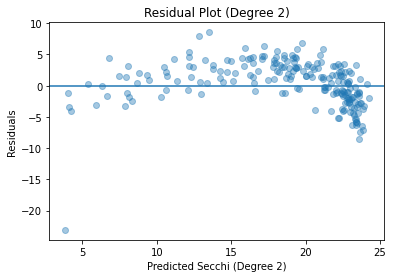

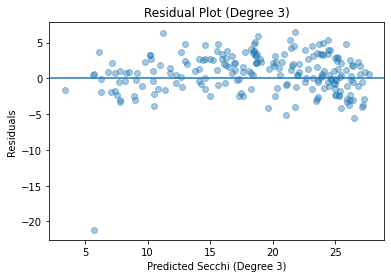

In [15]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Compute residuals
# -----------------------------

df.loc[:, "Residual_deg2"] = df["Predicted_Secchi_deg2"] - df["Pointvalue"]
df.loc[:, "Residual_deg3"] = df["Predicted_Secchi_deg3"] - df["Pointvalue"]

# -----------------------------
# 2. Residual plot (Degree 2)
# -----------------------------
plt.figure()
plt.scatter(df["Predicted_Secchi_deg2"], df["Residual_deg2"], alpha=0.4)
plt.axhline(0)  # reference line at zero
plt.xlabel("Predicted Secchi (Degree 2)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Degree 2)")
plt.show()

# -----------------------------
# 3. Residual plot (Degree 3)
# -----------------------------
plt.figure()
plt.scatter(df["Predicted_Secchi_deg3"], df["Residual_deg3"], alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted Secchi (Degree 3)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Degree 3)")
plt.show()

# Sanity check: only 213 rows have Pointvalue data and those are being evaluated.

In [14]:
# Ensure Pointvalue is numeric
df.loc[:, "Pointvalue"] = pd.to_numeric(df["Pointvalue"], errors="coerce")

# Keep only rows used in validation
df_valid = df.dropna(subset=["Pointvalue", "Predicted_Secchi_deg2", "Predicted_Secchi_deg3"])

# Count
print("Rows used for validation:", len(df_valid))

Rows used for validation: 213
